<a href="https://colab.research.google.com/github/AHMADAMJAD0/AI-LABS-BCS21242/blob/main/Hyperparameter_Tuning_the_ANN_using_Optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

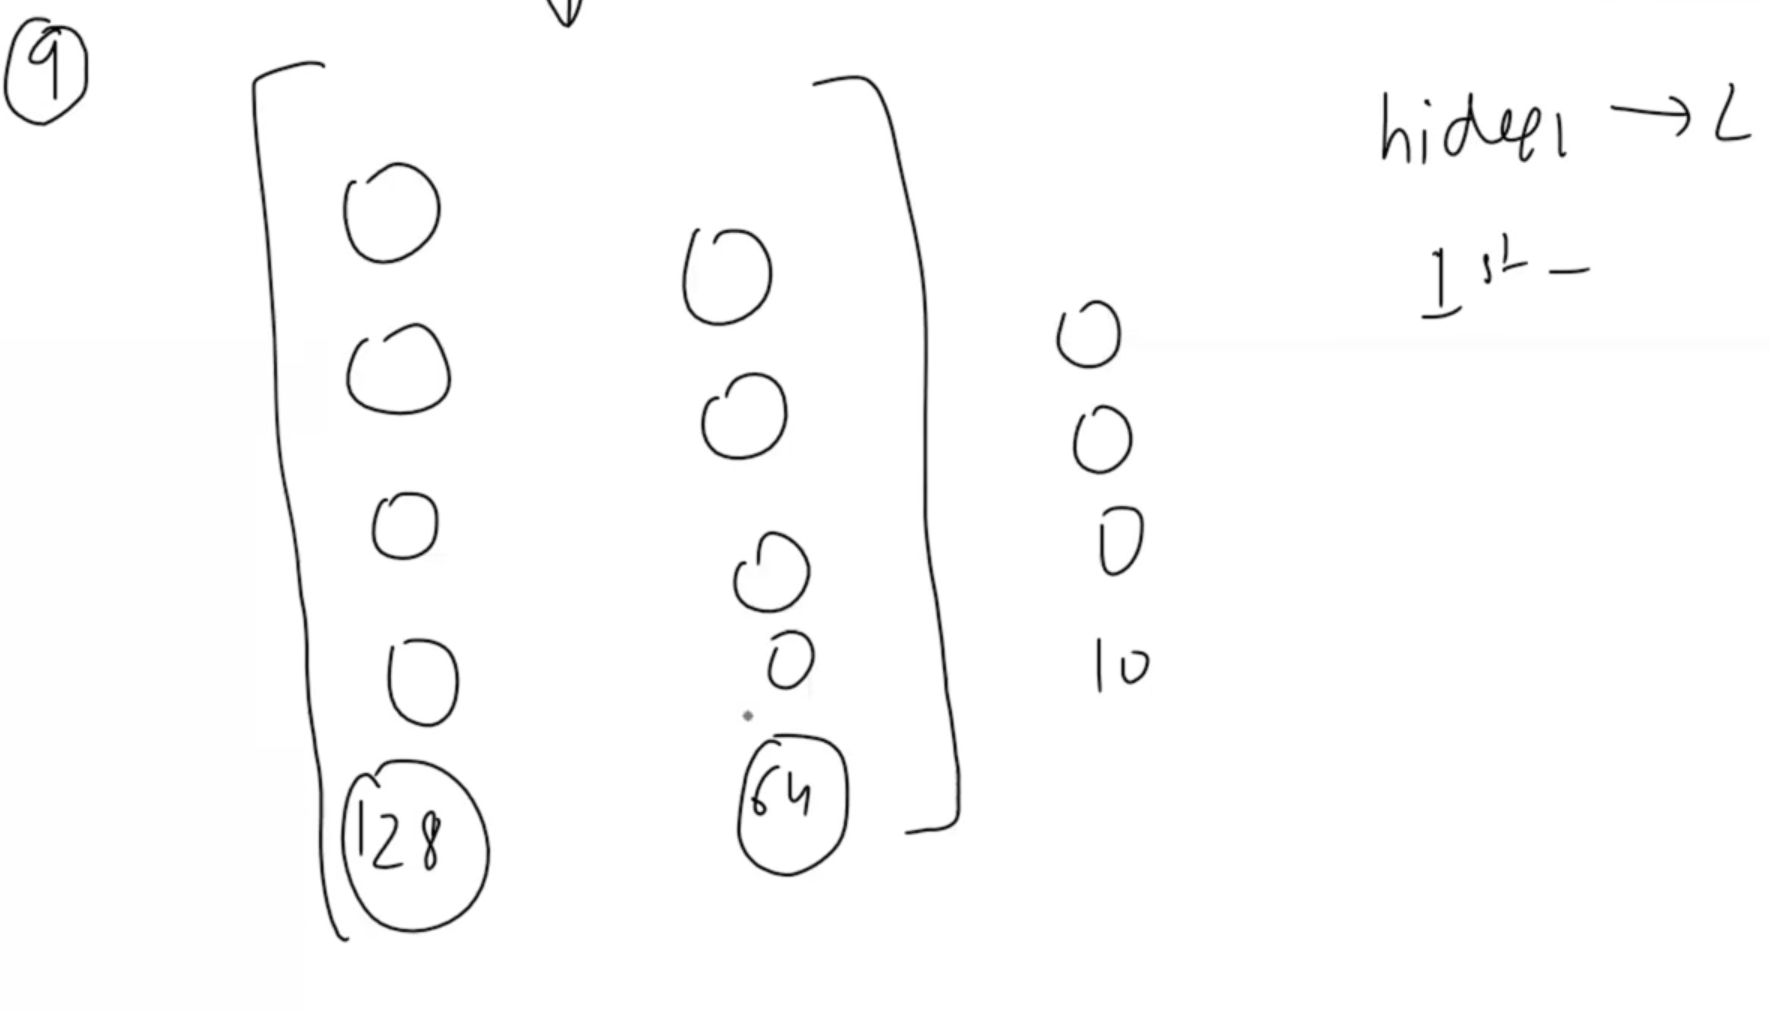

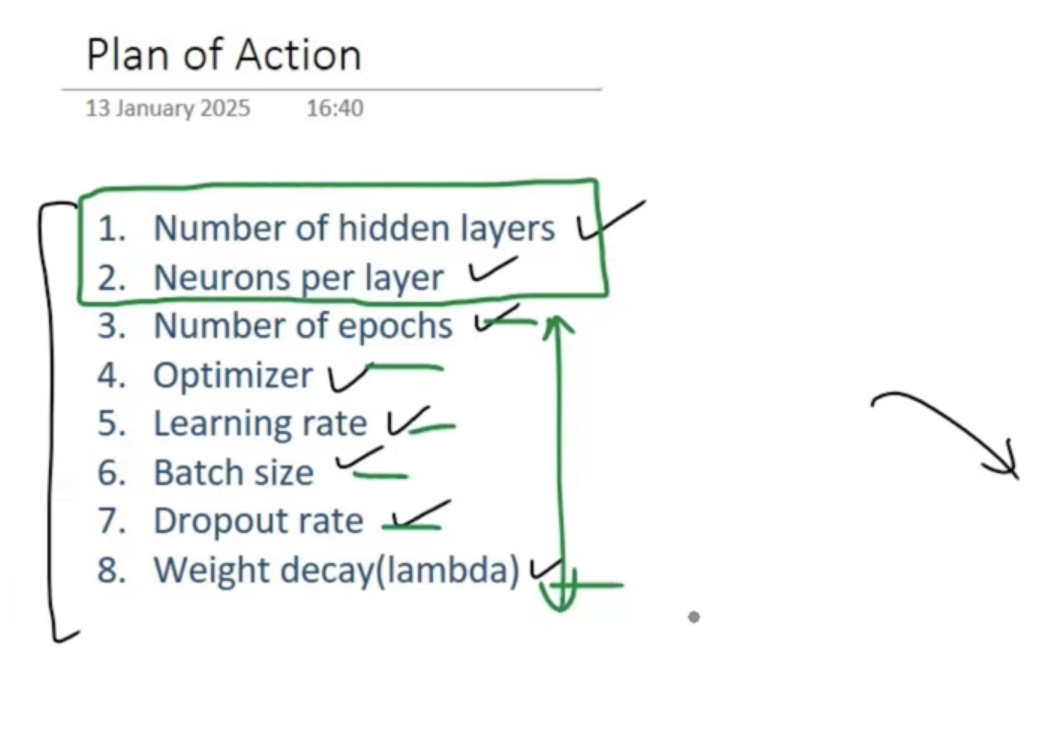





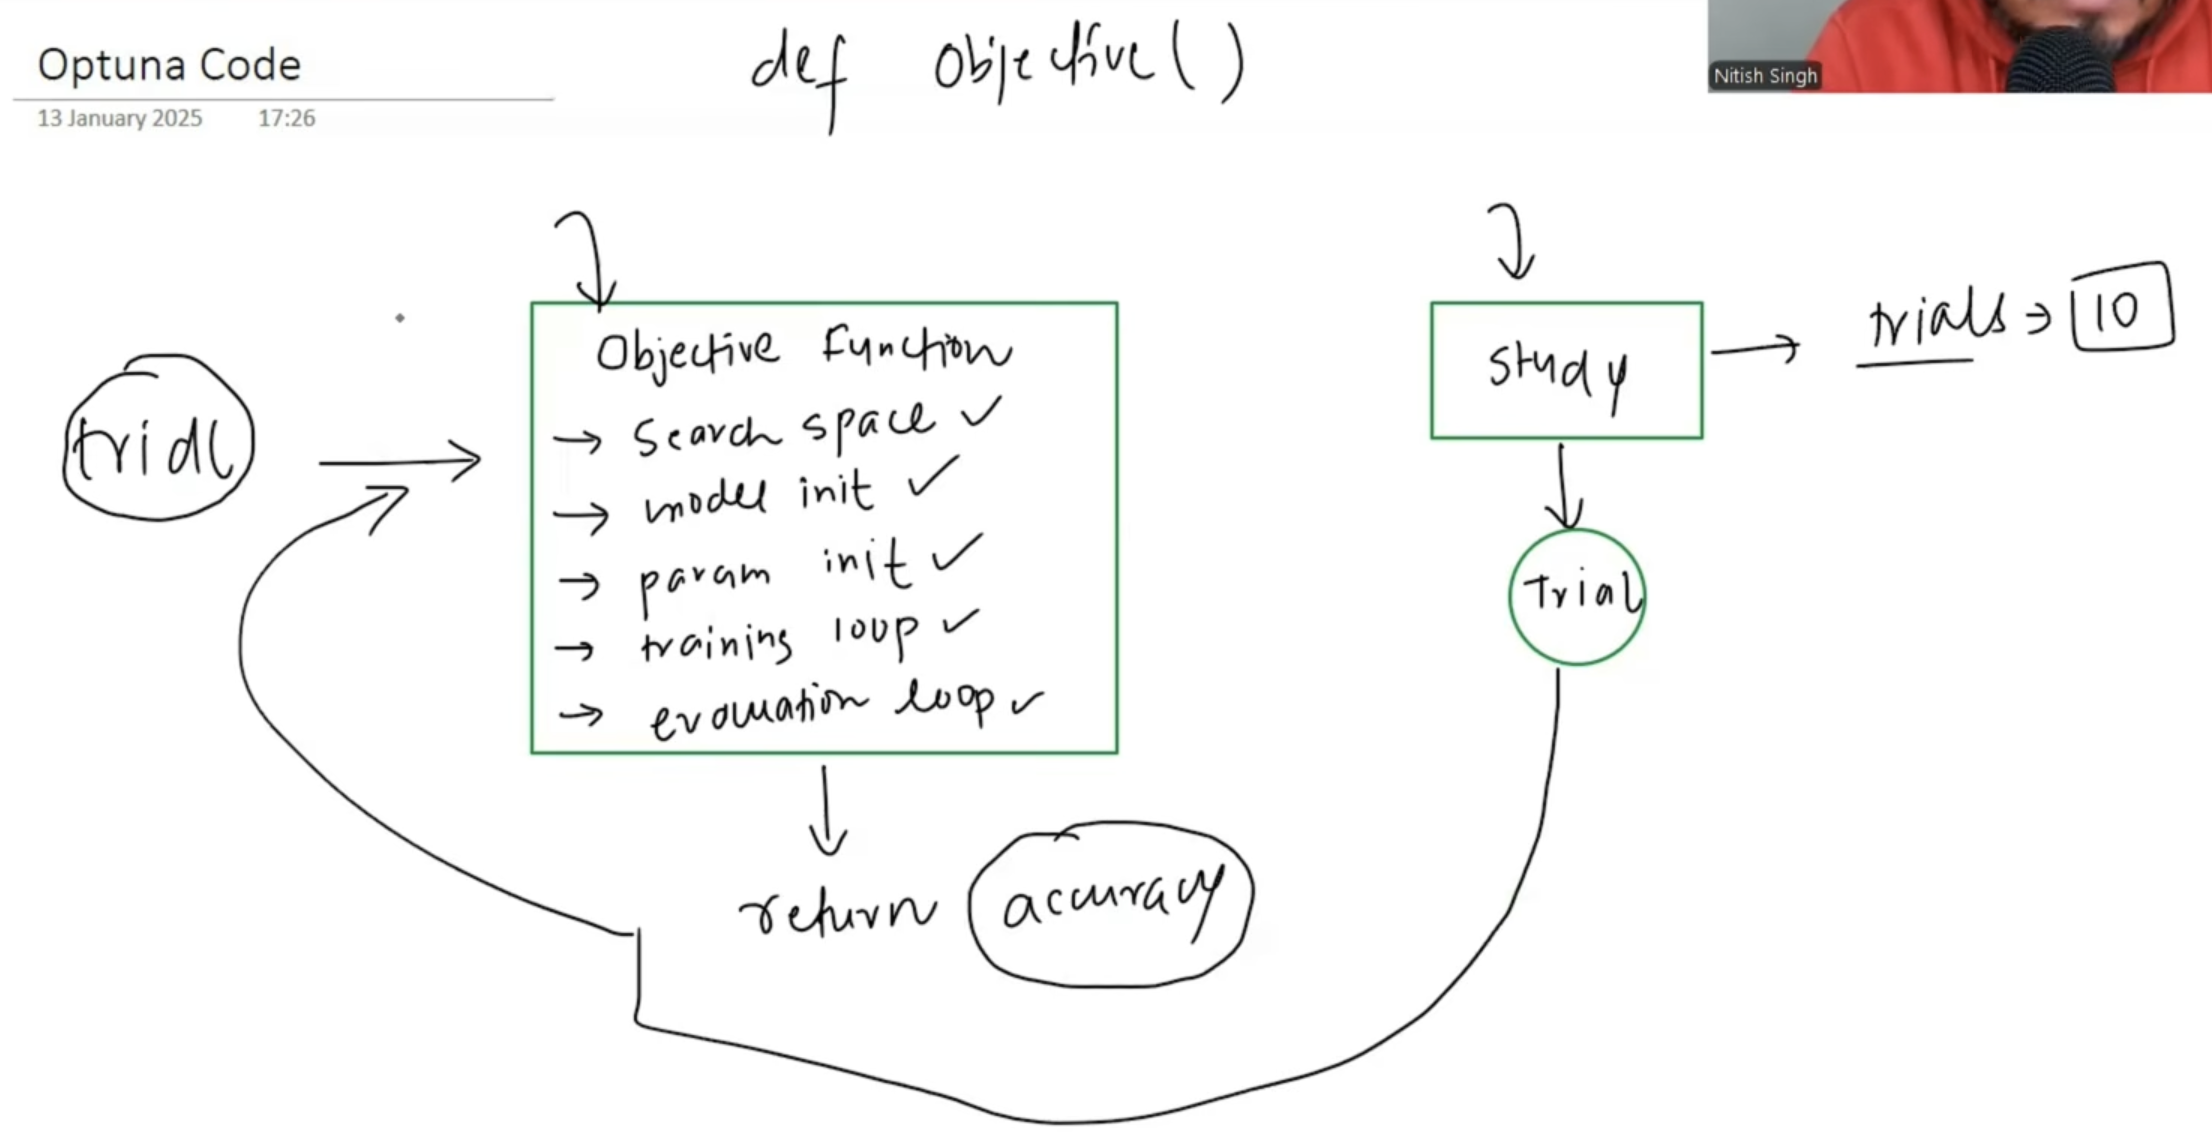

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [3]:
 # Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
df = pd.read_csv('/content/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

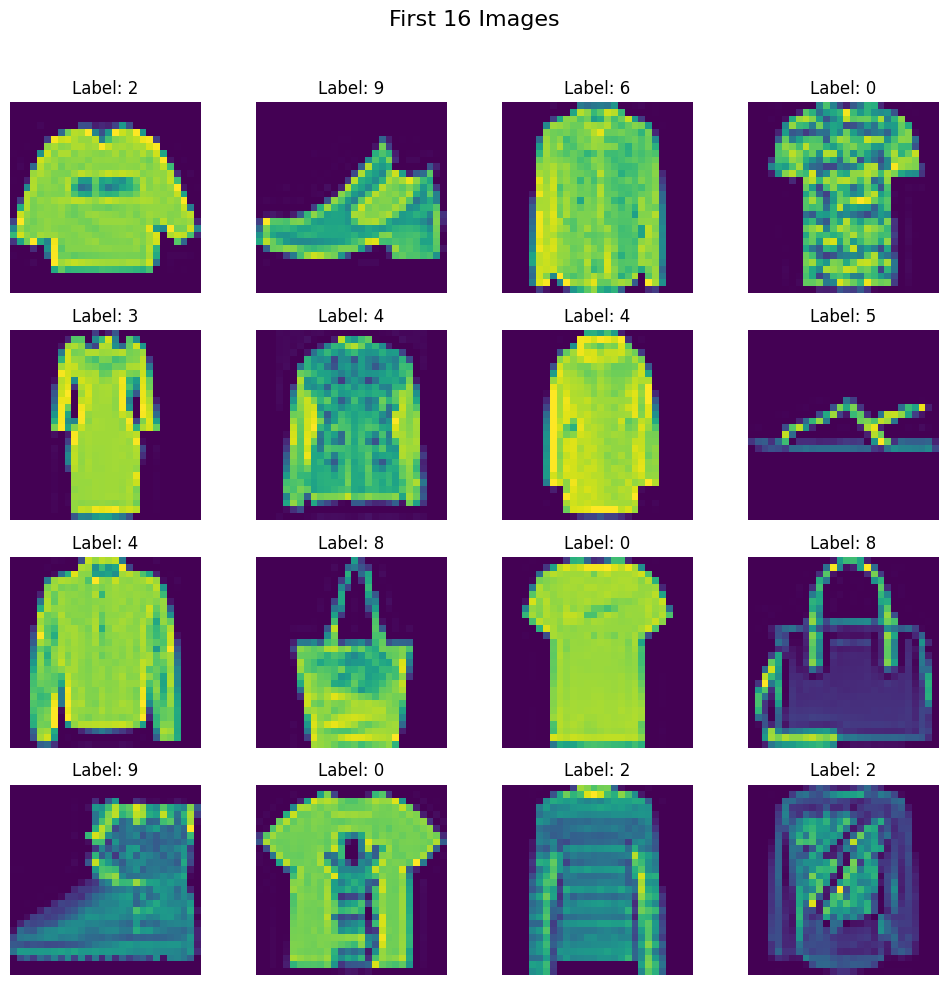

In [7]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [8]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train = X_train/255.0
X_test = X_test/255.0

In [11]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [12]:
X_test

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.82745098, 0.4       ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [13]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [14]:
train_dataset = CustomDataset(X_train, y_train)

In [15]:
test_dataset = CustomDataset(X_test, y_test)

In [16]:
len(train_dataset)

48000

In [17]:
from numpy.random import shuffle
# create train and test loader
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True , pin_memory= True)
test_loader = DataLoader(test_dataset , batch_size = 32 , shuffle = True , pin_memory= True)

In [18]:
len(train_loader)

1500

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

class MyNN(nn.Module):

    def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer):
        super().__init__()

        layers = []

        for i in range(num_hidden_layers):

            # Linear layer: input_dim -> neurons_per_layer
            layers.append(nn.Linear(input_dim, neurons_per_layer))

            # BatchNorm helps stabilize training
            layers.append(nn.BatchNorm1d(neurons_per_layer))

            # ReLU activation helps model learn non-linear patterns
            layers.append(nn.ReLU())

            # Dropout hels stabilize training
            layers.append(nn.Dropout(0.3))

            # After first layer, input size becomes neurons_per_layer
            input_dim = neurons_per_layer

        # Final output layer
        layers.append(nn.Linear(neurons_per_layer, output_dim))

        # Combine all layers in order
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [20]:
def objective(trial):

    # =========================
    # Step 1: Select hyperparameters using Optuna
    # =========================

    # Optuna will choose number of hidden layers between 1 and 5
    num_hidden_layers = trial.suggest_int(
        "num_hidden_layers",
        1,
        5
    )

    # Optuna will choose number of neurons per hidden layer
    # It will try values like 8, 16, 24, ..., 128
    neurons_per_layer = trial.suggest_int(
        "neurons_per_layer",
        8,
        128,
        step=8
    )

    # Optuna will choose learning rate between 0.0001 and 0.1
    # log=True means it will search in log scale, good for learning rate
    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-1,
        log=True
    )

    # =========================
    # Step 2: Create the neural network model
    # =========================

    # input_dim = number of input features/columns
    # output_dim = number of output classes
    # num_hidden_layers and neurons_per_layer are selected by Optuna
    input_dim = X_train.shape[1]
    output_dim = 10


    model = MyNN(
        input_dim,
        output_dim,
        num_hidden_layers,
        neurons_per_layer
    )

    # Send model to device: CPU or GPU
    model.to(device)

    # =========================
    # Step 3: Define loss function
    # =========================

    # CrossEntropyLoss is used for multi-class classification
    # For binary classification with CrossEntropyLoss, output_dim should be 2
    criterion = nn.CrossEntropyLoss()

    # =========================
    # Step 4: Define optimizer
    # =========================

    # Optimizer updates model weights and bias during training
    # learning_rate is selected by Optuna
    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # =========================
    # Step 5: Set number of epochs
    # =========================

    # epochs means how many times the model will train on the data
    epochs = 100

    # =========================
    # Step 6: Training mode
    # =========================

    # model.train() tells PyTorch we are training the model
    model.train()

    # =========================
    # Step 7: Training loop
    # =========================

    for epoch in range(epochs):

        # Store total loss for this epoch
        total_epoch_loss = 0

        # Loop through training data batch by batch
        for batch_features, batch_labels in train_loader:

            # Send batch data to CPU/GPU
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device).long()

            # -------------------------
            # Step 7.1: Forward pass
            # -------------------------

            # Send input features to model and get predictions
            outputs = model(batch_features)

            # -------------------------
            # Step 7.2: Calculate loss
            # -------------------------

            # Compare model predictions with actual labels
            loss = criterion(outputs, batch_labels)

            # -------------------------
            # Step 7.3: Clear old gradients
            # -------------------------

            # Important: gradients accumulate by default, so clear them first
            optimizer.zero_grad()

            # -------------------------
            # Step 7.4: Backward pass
            # -------------------------

            # Calculate gradients for all trainable parameters
            loss.backward()

            # -------------------------
            # Step 7.5: Update parameters
            # -------------------------

            # Optimizer updates weights and bias
            optimizer.step()

            # Add current batch loss to total epoch loss
            total_epoch_loss += loss.item()

    # =========================
    # Step 8: Evaluation mode
    # =========================

    # model.eval() tells PyTorch we are testing/evaluating the model
    model.eval()

    # Variables to calculate accuracy
    total = 0
    correct = 0

    # =========================
    # Step 9: Evaluate model on test data
    # =========================

    # no_grad means do not calculate gradients during testing
    with torch.no_grad():

        # Loop through test data batch by batch
        for batch_features, batch_labels in test_loader:

            # Send test batch data to CPU/GPU
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device).long()

            # -------------------------
            # Step 9.1: Forward pass on test data
            # -------------------------

            # Get model outputs for test data
            outputs = model(batch_features)

            # -------------------------
            # Step 9.2: Convert outputs into class predictions
            # -------------------------

            # torch.max returns maximum value and its index
            # predictions contains class index: 0, 1, 2, etc.
            _, predictions = torch.max(outputs, dim=1)

            # -------------------------
            # Step 9.3: Count total and correct predictions
            # -------------------------

            # Add number of samples in this batch
            total += batch_labels.shape[0]

            # Count how many predictions are correct
            correct += (predictions == batch_labels).sum().item()

    # =========================
    # Step 10: Calculate accuracy
    # =========================

    accuracy = correct / total

    # =========================
    # Step 11: Return accuracy to Optuna
    # =========================

    # Optuna will try to maximize this accuracy
    return accuracy

In [21]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.7 MB/s eta 0:00:00


In [22]:
import optuna

In [ ]:
# ceate study
study = optuna.create_study(direction="maximize")
study.optimize(objective , n_trials = 10)

[I 2026-07-21 04:45:59,030] A new study created in memory with name: no-name-9cedafe0-adf4-4d21-91e5-12502abb8cc4
[I 2026-07-21 04:54:43,303] Trial 0 finished with value: 0.8493333333333334 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 32, 'learning_rate': 0.0008563159342742534}. Best is trial 0 with value: 0.8493333333333334.
[I 2026-07-21 05:03:22,312] Trial 1 finished with value: 0.8935833333333333 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 120, 'learning_rate': 0.014389511089356627}. Best is trial 1 with value: 0.8935833333333333.
[I 2026-07-21 05:10:54,597] Trial 2 finished with value: 0.858 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 48, 'learning_rate': 0.00031842770669969267}. Best is trial 1 with value: 0.8935833333333333.
[I 2026-07-21 05:15:47,055] Trial 3 finished with value: 0.8818333333333334 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 72, 'learning_rate': 0.05179561436175847}. Best is trial 1 with val

In [ ]:
studt.best_value

In [ ]:
study.best_params

In [26]:
def objective(trial):
  num_hidden_layers = trial.suggest_init("num_hidden_layers" , 1 , 5)
  neurones_per_layers = trial.suggest_int("neurones_per_layers" , 8 , 128 , step = 8)
  epocs = trial.suggest_int("epocs" , 10 , 50 , step = 10)
  lerning_rate = trial.suggest_float("learning_rate " , 1e-4 , 1e-1 , log = True)
  dropout = trial.suggest_categorical("droput" , 0.2 , 0.5)
  batch_size = trial.suggest_categorical("batch_size" , 16 , 32 , 64 , 128 )
  optimizer = trial.suggest_categorical("optimizer" , ["Adom" , "SGD" , "RMSprop"])



  train_loader = DataLoader(train_dataset , batch_size = batch_size , shuffle = True , pin_memory = True)
  test_loader = DataLoader(test_dataset , batch_size = batch_size , shuffle = True , pin_memory = True)

In [27]:
optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )